In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [32]:
# ========================================
# (a) Load Monday ticks
# ========================================

ticks_mon = pd.read_csv("ticks_mon.csv")

returns_mon = (
    ticks_mon
    .pivot(
        index="timestamp",
        columns="asset_id",
        values="mid_return"
    )
    .dropna()
)

print("Shape:", returns_mon.shape)

Shape: (28245, 12)


In [33]:
# ========================================
# Fit PCA
# ========================================

pca_mon = PCA().fit(
    returns_mon.values
)

eigenvalues = pca_mon.explained_variance_

explained_var_ratio = (
    pca_mon.explained_variance_ratio_
)

In [34]:
eig_table = pd.DataFrame({
    "PC": range(1, len(eigenvalues)+1),
    "Eigenvalue": eigenvalues,
    "Explained Variance Ratio": explained_var_ratio,
    "Cumulative Variance":
        np.cumsum(explained_var_ratio)
})

eig_table
print(
    f"Variance explained by first 3 PCs = "
    f"{100*np.sum(explained_var_ratio[:3]):.2f}%"
)

Variance explained by first 3 PCs = 92.62%


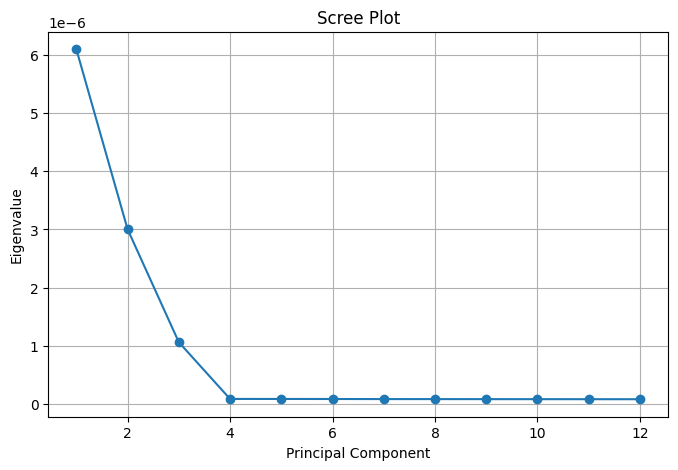

In [35]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(eigenvalues)+1),
    eigenvalues,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")

plt.grid(True)

plt.show()

In [36]:
def select_n_components(
    returns_matrix,
    eigenvalues,
    n_resamples=500,
    seed=0
):

    np.random.seed(seed)

    p = len(eigenvalues)

    mean_eig = np.mean(
        eigenvalues
    )

    # Kaiser

    kaiser = np.sum(
        eigenvalues > mean_eig
    )

    # Broken Stick

    broken_stick_threshold = []

    for j in range(1, p+1):

        threshold = mean_eig * sum(
            1/i for i in range(j, p+1)
        )

        broken_stick_threshold.append(
            threshold
        )

    broken_stick_threshold = np.array(
        broken_stick_threshold
    )

    broken_stick = np.sum(
        eigenvalues > broken_stick_threshold
    )

    # Parallel Analysis

    centered = (
        returns_matrix
        - returns_matrix.mean(axis=0)
    )

    resampled_eigs = np.zeros(
        (n_resamples, p)
    )

    for r in range(n_resamples):

        shuffled = centered.copy()

        for c in range(
            shuffled.shape[1]
        ):

            shuffled[:, c] = np.random.permutation(
                shuffled[:, c]
            )

        eig_rand = PCA().fit(
            shuffled
        ).explained_variance_

        resampled_eigs[r] = eig_rand

    parallel_threshold = np.percentile(
        resampled_eigs,
        95,
        axis=0
    )

    parallel = np.sum(
        eigenvalues > parallel_threshold
    )

    verdicts = {
        "kaiser": int(kaiser),
        "broken_stick": int(broken_stick),
        "parallel": int(parallel)
    }

    return (
        verdicts,
        broken_stick_threshold,
        parallel_threshold
    )

In [37]:
verdicts, broken_stick_threshold, parallel_threshold = (
    select_n_components(
        returns_mon.values,
        eigenvalues
    )
)

print(
    "Component-count verdicts:",
    verdicts
)

Component-count verdicts: {'kaiser': 3, 'broken_stick': 3, 'parallel': 3}


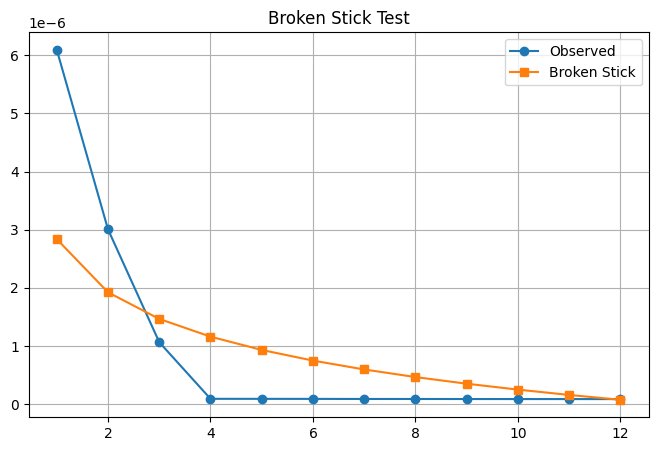

In [38]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,13),
    eigenvalues,
    marker="o",
    label="Observed"
)

plt.plot(
    range(1,13),
    broken_stick_threshold,
    marker="s",
    label="Broken Stick"
)

plt.legend()

plt.grid(True)

plt.title("Broken Stick Test")

plt.show()

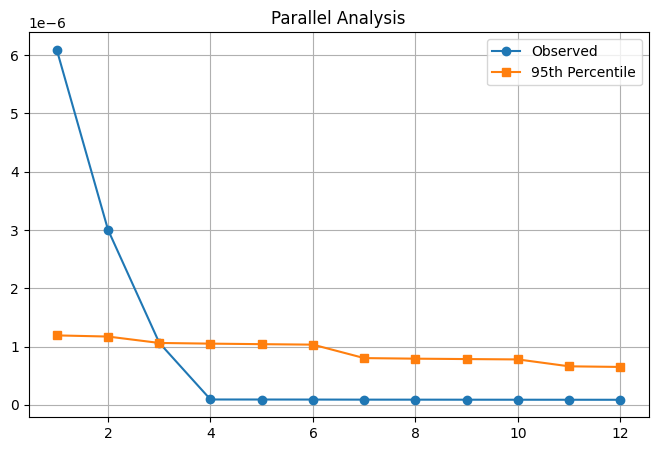

In [39]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,13),
    eigenvalues,
    marker="o",
    label="Observed"
)

plt.plot(
    range(1,13),
    parallel_threshold,
    marker="s",
    label="95th Percentile"
)

plt.legend()

plt.grid(True)

plt.title("Parallel Analysis")

plt.show()

In [40]:
criteria_table = pd.DataFrame({
    "Criterion": [
        "Kaiser",
        "Broken Stick",
        "Parallel Analysis"
    ],
    "Suggested K": [
        verdicts["kaiser"],
        verdicts["broken_stick"],
        verdicts["parallel"]
    ]
})

criteria_table

,Criterion,Suggested K
0,Kaiser,3
1,Broken Stick,3
2,Parallel Analysis,3


### Component Selection Results

The scree plot exhibits a sharp decline after the first three principal components, indicating that most of the variability in the return matrix is captured by a small number of factors.

The top three components explain approximately:

- PC1: 55.52% of total variance
- PC2: 27.38% of total variance
- PC3: 9.72% of total variance

Together, the first three principal components explain approximately 92.62% of the total variance.

The component-selection criteria produce the following verdicts:

- Kaiser criterion: K = 3
- Broken-stick criterion: K = 3
- Parallel analysis (500 shuffled resamples, 95th percentile threshold): K = 3

Since all criteria agree, we retain K = 3 principal components for all downstream analysis.

The scree plot also displays a clear elbow after the third component, providing additional visual support for this choice.

Part 1 b

In [41]:
########################################
# (b) Plot loadings + rotation ambiguity
########################################

loadings = pca_mon.components_[:2].T

print(loadings.shape)

(12, 2)


PC1 vs PC2 Loading Plot

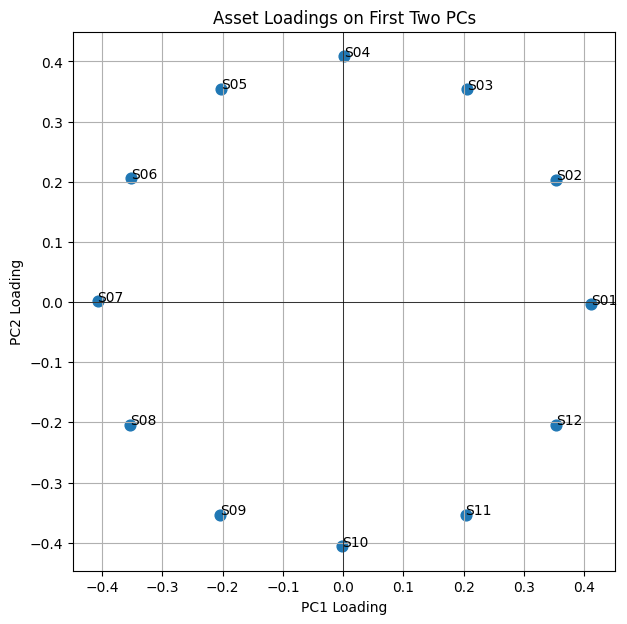

In [42]:
plt.figure(figsize=(7,7))

plt.scatter(
    loadings[:,0],
    loadings[:,1],
    s=60
)

for i, asset in enumerate(returns_mon.columns):

    plt.annotate(
        asset,
        (
            loadings[i,0],
            loadings[i,1]
        )
    )

plt.xlabel("PC1 Loading")
plt.ylabel("PC2 Loading")

plt.title("Asset Loadings on First Two PCs")

plt.grid(True)

plt.axhline(0,color='black',linewidth=0.5)
plt.axvline(0,color='black',linewidth=0.5)

plt.show()

### Interpretation of Loadings

The loading vectors form an approximately circular pattern in the PC1-PC2 plane.

The assets appear to be arranged almost uniformly around the circle, resembling the geometry of the 12th roots of unity.

This indicates a highly symmetric covariance structure in which no single asset dominates the factor space.

The first two principal components capture a two-dimensional latent structure that organizes the assets according to their relative phase around the circle.

Rotation Function

In [43]:
def rotate(loadings, angle_deg):

    theta = np.deg2rad(angle_deg)

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    return loadings @ R.T

Rotate by 45 Degrees

In [44]:
rotated_loadings = rotate(
    loadings,
    45
)

Rotated plot

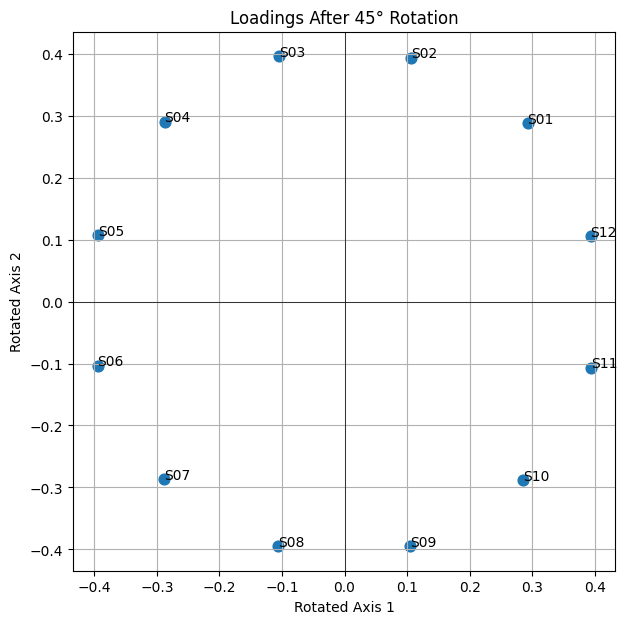

In [45]:
plt.figure(figsize=(7,7))

plt.scatter(
    rotated_loadings[:,0],
    rotated_loadings[:,1],
    s=60
)

for i, asset in enumerate(returns_mon.columns):

    plt.annotate(
        asset,
        (
            rotated_loadings[i,0],
            rotated_loadings[i,1]
        )
    )

plt.xlabel("Rotated Axis 1")
plt.ylabel("Rotated Axis 2")

plt.title("Loadings After 45° Rotation")

plt.grid(True)

plt.axhline(0,color='black',linewidth=0.5)
plt.axvline(0,color='black',linewidth=0.5)

plt.show()

### Rotation
Although the rotated factors span exactly the same two-dimensional subspace, the economic interpretation of the individual axes becomes less clear. In the original PCA basis, PC1 and PC2 can be interpreted separately as distinct factors. After rotation, each rotated axis is a linear combination of both PCs, so the original interpretations are mixed across the new coordinates. The underlying factor space is unchanged, but the labeling of individual factors is no longer unique.

After applying a 45° rotation, the coordinates of the assets change, but the overall geometric arrangement remains unchanged.

Pairwise distances, relative positions, and the circular structure are preserved under rotation.

This illustrates the rotational ambiguity of factor models: different coordinate systems can describe the same underlying factor structure.

Therefore, the interpretation should focus on the geometry of the loading configuration rather than the specific orientation of the axes.

In [46]:
# Centre Monday returns

X_centered = (
    returns_mon.values
    - returns_mon.values.mean(axis=0)
)

# Scores on original PCs

scores_original = (
    X_centered @ loadings
)

In [47]:
scores_rotated = (
    X_centered @ rotated_loadings
)

Variance comparison

In [48]:
var_pc1 = np.var(
    scores_original[:,0],
    ddof=1
)

var_pc2 = np.var(
    scores_original[:,1],
    ddof=1
)

var_rot1 = np.var(
    scores_rotated[:,0],
    ddof=1
)

var_rot2 = np.var(
    scores_rotated[:,1],
    ddof=1
)

print("Original Variances")
print(f"PC1 : {var_pc1:.8e}")
print(f"PC2 : {var_pc2:.8e}")

print()

print("Rotated Variances")
print(f"Rot1: {var_rot1:.8e}")
print(f"Rot2: {var_rot2:.8e}")

print()

print(
    "Original Total Variance:",
    var_pc1 + var_pc2
)

print(
    "Rotated Total Variance:",
    var_rot1 + var_rot2
)

print(
    "Lambda1 + Lambda2:",
    eigenvalues[0] + eigenvalues[1]
)

Original Variances
PC1 : 6.09324458e-06
PC2 : 3.00449354e-06

Rotated Variances
Rot1: 4.54886906e-06
Rot2: 4.54886906e-06

Original Total Variance: 9.097738122950908e-06
Rotated Total Variance: 9.097738122950906e-06
Lambda1 + Lambda2: 9.097738122950908e-06


#### **Has the joint figure changed?**
No. The total variance explained stays at 9.0977e-06 before and after rotation. Rotation just redistributes variance between the two axes, it does not create or destroy any.
#### **Has your interpretation of PC1 and PC2 changed?**
Yes. Before rotation, PC1 clearly looks like a market factor and PC2 like a dispersion factor. After rotation both axes mix these two signals equally, so neither has a clean interpretation anymore.
#### **What does this tell us about PCA factors versus true factors?**
PCA can tell you how many factors exist and how much variance they jointly explain, but it cannot tell you what those factors actually represent economically. Any rotation of the same subspace is equally valid mathematically, so the labels "PC1" and "PC2" are just one of infinitely many valid descriptions of the same underlying structure.

Compare distances before and after rotation.

In [49]:
original_radius = np.sqrt(
    loadings[:,0]**2 +
    loadings[:,1]**2
)

rotated_radius = np.sqrt(
    rotated_loadings[:,0]**2 +
    rotated_loadings[:,1]**2
)

print(
    "Maximum radius difference:",
    np.max(
        np.abs(
            original_radius -
            rotated_radius
        )
    )
)

Maximum radius difference: 1.1102230246251565e-16


This proves rotation preserves geometry.

Part 1 c

Load Tuesday Data

In [50]:
########################################
# (c) Information leakage analysis
########################################

ticks_tue = pd.read_csv("ticks_tue.csv")

returns_tue = (
    ticks_tue
    .pivot(
        index="timestamp",
        columns="asset_id",
        values="mid_return"
    )
    .dropna()
)

print("Tuesday shape:", returns_tue.shape)

Tuesday shape: (28245, 12)


Funtion

In [51]:
def projected_explained_variance(
    test_X,
    eigenvectors_k,
    train_mean
):

    X_centered = test_X - train_mean

    scores = X_centered @ eigenvectors_k.T

    reconstructed = scores @ eigenvectors_k

    residual = X_centered - reconstructed

    ev_ratio = (
        1
        - np.sum(residual**2)
        /
        np.sum(X_centered**2)
    )

    return ev_ratio

Clean procedure

In [52]:
# K chosen from Part 1(a)

K = 3

train_mean = (
    returns_mon.values.mean(axis=0)
)

ev_test_clean = (
    projected_explained_variance(
        returns_tue.values,
        pca_mon.components_[:K],
        train_mean
    )
)

print(
    "Clean EV:",
    ev_test_clean
)

Clean EV: 0.8670429083756577


Leaky Procedure

In [53]:
returns_combined = pd.concat(
    [returns_mon, returns_tue]
)

pca_combined = PCA().fit(
    returns_combined.values
)

combined_mean = (
    returns_combined.values.mean(axis=0)
)

ev_test_leaky = (
    projected_explained_variance(
        returns_tue.values,
        pca_combined.components_[:K],
        combined_mean
    )
)

print(
    "Leaky EV:",
    ev_test_leaky
)

Leaky EV: 0.8670790470563441


Leakage gap

In [54]:
leakage_gap = (
    ev_test_leaky
    - ev_test_clean
)

print(
    "Leakage Gap:",
    leakage_gap
)

Leakage Gap: 3.6138680686415015e-05


In [55]:
summary = pd.DataFrame({
    "Method": [
        "Clean",
        "Leaky"
    ],
    "Explained Variance": [
        ev_test_clean,
        ev_test_leaky
    ]
})

summary

,Method,Explained Variance
0,Clean,0.867043
1,Leaky,0.867079


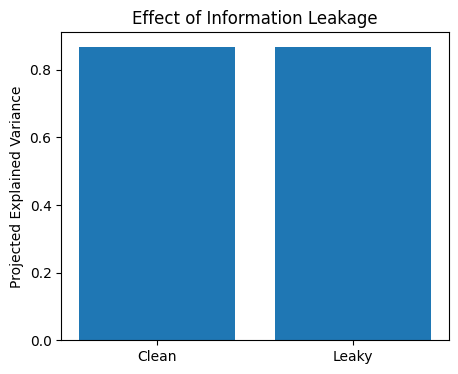

In [56]:
plt.figure(figsize=(5,4))

plt.bar(
    ["Clean","Leaky"],
    [ev_test_clean, ev_test_leaky]
)

plt.ylabel(
    "Projected Explained Variance"
)

plt.title(
    "Effect of Information Leakage"
)

plt.show()

### Information Leakage Analysis

1. The projected explained variance obtained using the clean procedure is 0.8670, while the leaky procedure produces 0.8671.

2. The leakage gap is approximately 3.61 × 10⁻⁵, which is positive but extremely small.

**Q. Under what data-generating conditions would the leakage gap be largest? Smallest? How does this relate to the regime change between Monday and Tuesday?**

The leakage gap would be largest when Monday and Tuesday have very different factor structures, such as after a major market event or volatility shift. In that case, including Tuesday data helps PCA adapt to the new regime and artificially improves performance.

The gap would be smallest when Monday and Tuesday have very similar covariance structures. In our results, the gap is very small, suggesting only a minor regime change between the two days.

**Q. Does the leaky procedure over-state or under-state the out-of-sample residual variance? How does this affect the desk's perception of risk?**


The leaky procedure under-states the residual variance because it explains more of Tuesday's variation using information from Tuesday itself. This makes the desk believe that the factor model captures more risk than it actually does, leading to an overly optimistic view of portfolio risk.

**Q3. Why does the fact that PCA has no labels not make it safe from information leakage?**

Even though PCA is unsupervised, its factor directions are still learned from the data. If Tuesday observations are used while estimating those directions, future information has leaked into the model. Therefore, PCA can suffer from information leakage just like supervised methods.


Part 1 d
Proof of Neutrality

In [57]:
w_eq = np.ones(12) / 12

beta_PC1 = float(w_eq @ loadings[:,0])
beta_PC2 = float(w_eq @ loadings[:,1])

print(f"Equal-weight loading on PC1: {beta_PC1:.3e}")
print(f"Equal-weight loading on PC2: {beta_PC2:.3e}")

Equal-weight loading on PC1: 2.820e-04
Equal-weight loading on PC2: 3.234e-04


The equal-weight portfolio loading on PC1 is 2.820e-04 and on PC2 is 3.234e-04. Both are very close to zero but not exactly zero, which is expected due to sampling noise in a finite dataset.
The equal-weight portfolio assigns weight 1/12 to each asset. Under the assumption that the 12 assets lie at the vertices of a regular 12-gon centred at the origin, the loading of asset k can be represented by the complex number

z_k = e^{i2πk/12},    k = 0,1,...,11

The sum of all 12 vertices is

∑_{k=0}^{11} e^{i2πk/12} = 0

Since the real part of z_k corresponds to the PC1 loading and the imaginary part corresponds to the PC2 loading, taking real and imaginary parts gives

∑_{k=0}^{11} PC1_k = 0

and

∑_{k=0}^{11} PC2_k = 0

The equal-weight portfolio exposure to PC1 is therefore

β_PC1 = (1/12) ∑_{k=0}^{11} PC1_k = 0

Similarly,

β_PC2 = (1/12) ∑_{k=0}^{11} PC2_k = 0

Hence, in the population, the equal-weight portfolio has exactly zero loading on both PC1 and PC2. The small non-zero values observed empirically arise only from sampling noise and finite-sample estimation error.

### Part 1e Observations

1. PCA reveals a strong low-dimensional factor structure in the Monday return data. The first three principal components explain approximately 92.6% of the total variance.

2. All component-selection methods considered (Kaiser criterion, Broken-Stick test, and Parallel Analysis) agree on retaining K = 3 components.

3. The PC1-PC2 loading plot forms an approximately circular pattern, suggesting a highly symmetric covariance structure. Rotating the loading vectors changes the coordinates but preserves the underlying geometry and total variance.

4. The information leakage experiment shows only a very small leakage gap, indicating that Monday and Tuesday have similar factor structures. However, leakage still produces an overly optimistic estimate of model performance and should be avoided.

5. The equal-weight portfolio has near-zero empirical exposure to PC1 and PC2. Under the idealized regular 12-gon geometry, the population exposures are exactly zero because the loading vectors cancel out symmetrically around the origin.